In [81]:
from astropy.io import fits

hdul = fits.open(r"hlsp_hugs_hst_acs-wfc_ngc3201_f814w_v1_stack-0100s.fits")

print(hdul.info())

Filename: hlsp_hugs_hst_acs-wfc_ngc3201_f814w_v1_stack-0100s.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      36   (10000, 10000)   float32   
None


In [82]:
''' Extract the channels '''

image = hdul[0].data
instrument = hdul[0].header.get("INSTRUME")
fil = hdul[0].header.get("FILTER")
print(image)

[[-25. -25. -25. ... -25. -25. -25.]
 [-25. -25. -25. ... -25. -25. -25.]
 [-25. -25. -25. ... -25. -25. -25.]
 ...
 [-25. -25. -25. ... -25. -25. -25.]
 [-25. -25. -25. ... -25. -25. -25.]
 [-25. -25. -25. ... -25. -25. -25.]]


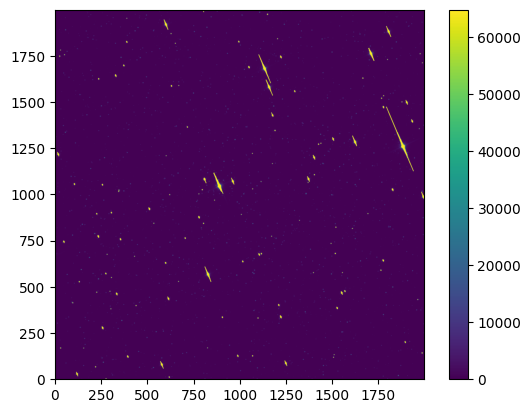

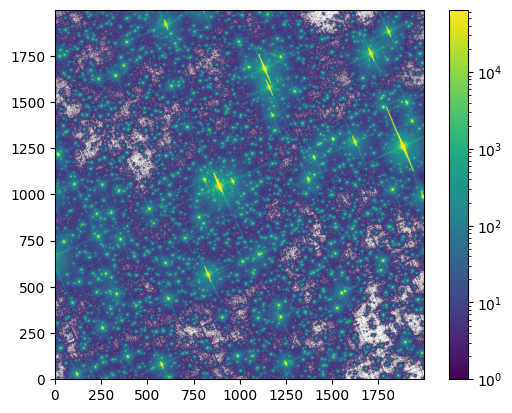

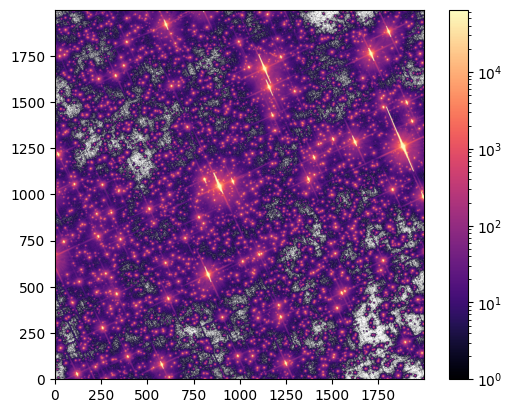

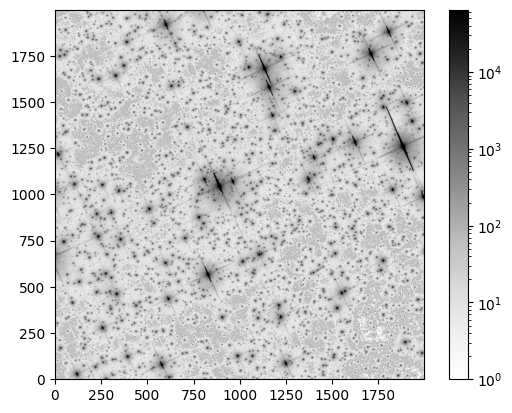

In [83]:
''' Image Plot '''


import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

image = image[4000:6000, 4000:6000]

plt.figure()
plt.imshow(image, origin = 'lower')
plt.colorbar()
plt.show()


plt.figure()
plt.imshow(image, origin = 'lower', norm = LogNorm())
plt.colorbar()
plt.show()


plt.figure()
plt.imshow(image, origin = 'lower', norm = LogNorm(), cmap = 'magma')
plt.colorbar()
plt.show()


plt.figure()
plt.imshow(image, origin = 'lower', norm = LogNorm(), cmap = 'Greys')
plt.colorbar()
plt.show()



In [84]:
''' Stars Detection '''


from photutils.detection import DAOStarFinder
from astropy.stats import sigma_clipped_stats


# 1. Estimate background mean, median, and std deviation
mean, median, std = sigma_clipped_stats(image, sigma=3.0)

# 2. Find stars at least 5-sigma above background
daofind = DAOStarFinder(fwhm=3.0, threshold=5.0 * std)
sources = daofind(image - median)


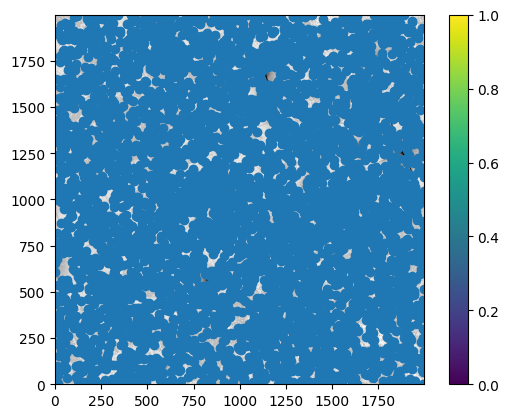

4633 radiation emmitting bodies found


In [85]:
x = sources['x_centroid']
y = sources['y_centroid']

plt.figure()
plt.imshow(image, origin = 'lower', norm = LogNorm(), cmap = 'Greys')
plt.scatter(x,y)
plt.colorbar()
plt.show()

print(f"{len(sources)} radiation emmitting bodies found")

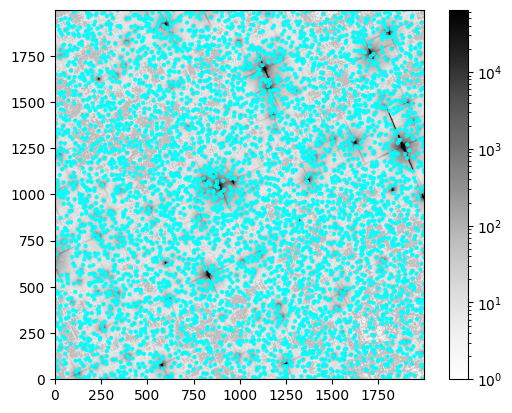

In [86]:
''' Aperture circling'''
import numpy as np
from photutils.aperture import CircularAperture

positions = np.transpose((x,y))

apertures = CircularAperture(positions, r=6.0)


plt.figure()
plt.imshow(image, origin = 'lower', norm = LogNorm(), cmap = 'Greys')

# Plot hollow circle outlines
apertures.plot(
    color='cyan',       # Outline color
    lw=1.5,             # Line width / thickness
    alpha=0.9           # Transparency
)

plt.colorbar()
plt.show()


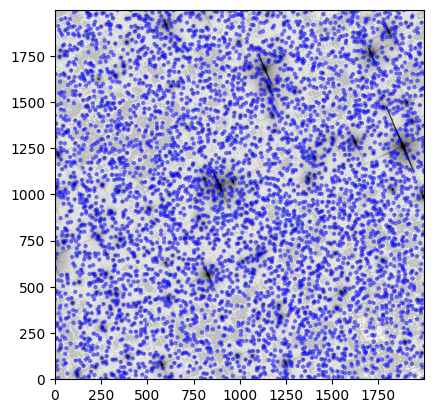

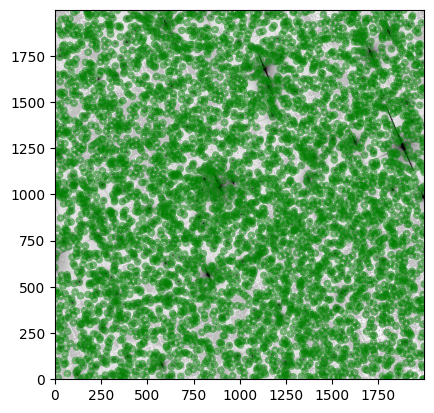

 id   x_center  y_center  aperture_sum total_bkg
---- --------- ---------- ------------ ---------
   1 356.91494 0.60301585     9275.172   835.172
   2 810.11275  0.4272179    121596.88 1628.0646
   3 1092.6255 0.29010111    106411.23 1770.7411
   4 1781.5041 0.48317008    5634.9933 15714.739
   5 1797.5829 0.30751949     97226.68 2007.3832
   6 1990.4212  0.3384967     13551.57 37.179799
   7 1998.6264 0.54382365    4158.3612 649.87332
   8 144.20055  1.1860649    31532.222 4716.3367
   9 275.32687  1.0476218    1117476.4 8621.6363
  10 399.15076  1.2735332    3499.6911 369.55757
 ...       ...        ...          ...       ...
4624  410.4903   1996.845    4730.8191 1931.6671
4625 1007.9818  1996.5966    12365.283 2725.3179
4626 1388.7404  1997.6369    5736.4065 187.98857
4627  1888.035  1996.4914    138111.62 1648.7181
4628 177.50669  1998.0579     21687.68 17715.112
4629 489.53064  1997.8755    14604.273 5173.8968
4630 795.30785  1998.0678    1768706.9 434112.43
4631 1822.5817  1997

In [87]:
''' Aperture Photometry'''


# Define background Annulli

from photutils.aperture import CircularAnnulus, CircularAperture, aperture_photometry, ApertureStats

annulus_aperture = CircularAnnulus(positions, r_in = 10, r_out = 15)

plt.figure()
plt.imshow(image, cmap = 'Greys', origin = 'lower', norm = LogNorm())
apertures.plot(color = 'blue', lw = 1.5, alpha = 0.5)
plt.show()


plt.figure()
plt.imshow(image, cmap = 'Greys', origin = 'lower', norm = LogNorm())
annulus_aperture.plot(color = 'green', lw = 1.5, alpha = 0.5)
plt.show()



# Get stats

aperture_stats = ApertureStats(image , annulus_aperture)
bkg_mean = aperture_stats.mean
aperture_area = apertures.area_overlap(image)

total_bkg = bkg_mean*aperture_area
star_data = aperture_photometry(image, apertures)
star_data['total_bkg'] = total_bkg

for col in star_data.colnames:
    star_data[col].info.format = '%.8g'

star_data.pprint()


In [88]:

''' Fetch the Zero-Point'''
from acstools import acszpt

filt='F814W'

# Specify the observation parameters manually
q = acszpt.Query(
    date='2006-03-14',
    detector='WFC'
)

# Fetch the zero points
zpt_table = q.fetch()


q_filter = acszpt.Query(date = '2006-03-14', detector = "WFC", filt = filt)

filter_zpt = q_filter.fetch()

print(filter_zpt)


Filter PHOTLAM             PHOTFLAM            STmag  VEGAmag  ABmag 
       Angstrom erg / (Angstrom electron cm2) mag(ST)   mag   mag(AB)
------ -------- ----------------------------- ------- ------- -------
 F814W   8047.9                    7.0157e-20  26.785  25.517  25.948


In [89]:
''' Fetch the magnitude of each detected star '''


import math

zero_point = 25.948
exptime =  hdul[0].header["EXPTIME"]
magnitudes = []
for line in star_data:
    numerator = abs(line[3] - line[4])
    mag = zero_point - 2.5 * (math.log10(numerator/exptime))
    magnitudes.append(mag)

star_data['Magnitudes'] = magnitudes

star_data.pprint()


 id   x_center  y_center  aperture_sum total_bkg     Magnitudes    
---- --------- ---------- ------------ --------- ------------------
   1 356.91494 0.60301585     9275.172   835.172  22.63729385840646
   2 810.11275  0.4272179    121596.88 1628.0646 19.755479035017665
   3 1092.6255 0.29010111    106411.23 1770.7411 19.903900597723144
   4 1781.5041 0.48317008    5634.9933 15714.739  22.44452604487381
   5 1797.5829 0.30751949     97226.68 2007.3832 20.006337558399935
   6 1990.4212  0.3384967     13551.57 37.179799   22.1261588092809
   7 1998.6264 0.54382365    4158.3612 649.87332 23.590350017363793
   8 144.20055  1.1860649    31532.222 4716.3367 21.382169638945626
   9 275.32687  1.0476218    1117476.4 8621.6363 17.340963347721996
  10 399.15076  1.2735332    3499.6911 369.55757  23.71424280227972
 ...       ...        ...          ...       ...                ...
4624  410.4903   1996.845    4730.8191 1931.6671 23.835583794278712
4625 1007.9818  1996.5966    12365.283 2725.3179